In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [16]:
import random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import MeanAggregation, SumAggregation

from tqdm.auto import tqdm

from bcos.modules import BcosLinear
from bcosgnn.explain_edge_attr import explain as explain_edge_attr
import os
import shutil
from torch_geometric.data import InMemoryDataset
import tqdm
import sys
import os
# Add the project root to the Python path
if project_root not in sys.path:
    sys.path.append(project_root)

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import TUDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import torch.nn.functional as F
from bcosgnn.explain import explain
from bcosgnn.evaluation import get_attribution_scores

In [17]:
import importlib
import bcosgnn.evaluation
importlib.reload(bcosgnn.evaluation)
from bcosgnn.evaluation import get_attribution_scores

## BCos Model Definitions
We define the B-Cos GNN model components (Readout, GIN Layer, and the full GNN).

In [18]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out

class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out



In [19]:
class BcosGINEConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        edge_dim: int,
        b: float = 2.0,
        max_out: int = 1,
        eps: float = 0.0,
        train_eps: bool = False,
        **kwargs
    ):
        # We use 'add' aggregation to stay true to the GIN formula
        kwargs.setdefault("aggr", "add")
        super().__init__(**kwargs)
        
        # The MLP part of GIN, using B-cos layers to preserve dynamic linearity
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.Tensor([eps]))
        else:
            self.register_buffer("eps", torch.Tensor([eps]))

    def forward(self, x, edge_index, edge_attr):
        # edge_attr is expected to be pre-projected to match x dimension
        
        # 1. Propagate messages
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        
        # 2. Combine step: (1 + eps) * center_node + aggregated_messages
        out = (1 + self.eps) * x + out
        
        # 3. Apply the B-cos MLP transformation
        return self.transform(out)

    def message(self, x_j, edge_attr):
        # STRICT LINEARITY: Just add the edge attributes. 
        # No standard ReLUs allowed!
        return x_j + edge_attr

In [20]:
class PureBcosGINE(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        hidden_dim: int = 128,
        num_layers: int = 4,
        num_classes: int = 1,
        b: float = 2.0,
        max_out: int = 1,
        dropout: float = 0.5, 
    ):
        super().__init__()
        
        # 1. Initial Embeddings
        self.lin_node = BcosLinear(node_dim, hidden_dim, b=b, max_out=max_out)
        self.lin_edge = BcosLinear(edge_dim, hidden_dim, b=b, max_out=max_out)
        
        # 2. Convolutional Layers
        self.convs = nn.ModuleList([
            BcosGINEConv(
                channels=[hidden_dim, hidden_dim], 
                edge_dim=hidden_dim, 
                b=b, 
                max_out=max_out
            ) for _ in range(num_layers)
        ])
        
        # 3. Readout Components (Readout-Then-Aggregate Strategy)
        self.readout_hidden = BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out)
        self.dropout_layer = nn.Dropout(dropout)
        self.readout_out = BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)
        
        # 4. Aggregation
        self.agg = SumAggregation()

    def forward(self, x, edge_index, edge_attr, batch):
        x = x.float()
        edge_attr = edge_attr.float()
        x = self.lin_node(x)
        e = self.lin_edge(edge_attr)
        
        for conv in self.convs:
            x = conv(x, edge_index, e)
        
        # Readout Then Agg logic
        
        # Step A: Transform node features through the hidden readout
        x = self.readout_hidden(x)
        
        # Step B: Apply dropout to the hidden representations (not the final logits)
        x = self.dropout_layer(x)
        
        # Step C: Project to class logits
        node_logits = self.readout_out(x)
        
        # Step D: Aggregate into graph-level logits
        graph_logits = self.agg(node_logits, batch)
        
        return graph_logits.squeeze(-1)

## Dataset Loading and Statistics
We load the MUTAG dataset from TUDataset.
- **Class 0**: Mutagenic
- **Class 1**: Non-mutagenic
- **Node Features**: 14 one-hot encoded atom types.
- **Ground Truth**: Mutagenicity is typically caused by nitro ($NO_2$) or amino ($NH_2$) groups attached to aromatic rings.

In [21]:
# Load Dataset (pre-saved .pt with node ground-truth masks)
dataset_path = project_root / "shaique_updates" / "codes" / "mutag_experiments" / "mutag_balanced_explainability.pt"
if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {dataset_path}")

dataset_obj = torch.load(dataset_path, map_location="cpu", weights_only=False)

def _is_data_obj(obj):
    return hasattr(obj, "x") and hasattr(obj, "edge_index")

def _flatten_dict_dataset(dct):
    values = list(dct.values())
    # If values are Data objects
    if all(_is_data_obj(v) for v in values):
        return list(values)
    # If values are lists/tuples of Data objects
    if all(isinstance(v, (list, tuple)) for v in values):
        flat = []
        for v in values:
            flat.extend(list(v))
        return flat
    # If one common key holds the dataset
    for key in ("dataset", "data", "graphs", "items"):
        if key in dct:
            return list(dct[key]) if not isinstance(dct[key], list) else dct[key]
    return list(dct)  # fallback to keys (likely wrong, but explicit)

if isinstance(dataset_obj, dict):
    dataset = _flatten_dict_dataset(dataset_obj)
elif isinstance(dataset_obj, (list, tuple)):
    dataset = list(dataset_obj)
else:
    dataset = dataset_obj

# Normalize to a list for downstream splitting/statistics
if not isinstance(dataset, list):
    dataset = list(dataset)

print(f"Loaded dataset from: {dataset_path}")
print(f"Number of graphs: {len(dataset)}")

def _get_label(d):
    y = d.y
    if torch.is_tensor(y):
        return int(y.view(-1)[0].item())
    return int(y)

def _get_num_features(d):
    return int(d.x.shape[-1])

num_features = _get_num_features(dataset[0])
edge_dim = int(dataset[0].edge_attr.shape[-1]) if getattr(dataset[0], "edge_attr", None) is not None else 0
print(f"Number of features: {num_features}")
print(f"Edge attr dim: {edge_dim}")

# Statistics
class_counts = {0: 0, 1: 0}
total_nodes = 0
class_nodes = {0: 0, 1: 0}

for data in dataset:
    y = _get_label(data)
    class_counts[y] += 1
    total_nodes += data.num_nodes
    class_nodes[y] += data.num_nodes

print(f"\nClass Distribution:")
print(f"  Class 0 (Mutagenic):     {class_counts[0]} graphs")
print(f"  Class 1 (Non-mutagenic): {class_counts[1]} graphs")

print(f"\nNode Statistics:")
print(f"  Average nodes (Total):   {total_nodes / len(dataset):.2f}")
print(f"  Average nodes (Class 0): {class_nodes[0] / class_counts[0]:.2f}")
print(f"  Average nodes (Class 1): {class_nodes[1] / class_counts[1]:.2f}")

# Split Dataset
labels = [_get_label(d) for d in dataset]
train_dataset, test_dataset = train_test_split(
    dataset, test_size=0.2, random_state=42, stratify=labels
 )
print(f"\nTrain set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Loaded dataset from: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/mutag_experiments/mutag_balanced_explainability.pt
Number of graphs: 2030
Number of features: 14
Edge attr dim: 3

Class Distribution:
  Class 0 (Mutagenic):     1015 graphs
  Class 1 (Non-mutagenic): 1015 graphs

Node Statistics:
  Average nodes (Total):   29.29
  Average nodes (Class 0): 27.55
  Average nodes (Class 1): 31.02

Train set size: 1624
Test set size: 406


In [22]:
# Inspect GT node mask sizes in the dataset
# NOTE: The dataset was created from the evaluation subset in mutag_eda.ipynb:
#   - Class 0 (Mutagenic): ~1015 graphs WITH ground-truth NO2/NH2 motifs
#   - Class 1 (Non-mutagenic): ~1015 graphs WITHOUT ground-truth masks (sampled for balance)
# Therefore, we expect masks ONLY on Class 0 samples.

def _extract_mask_size(d):
    for name in ("explanation_mask", "node_mask", "node_gt_mask", "gt_node_mask"):
        if hasattr(d, name) and getattr(d, name) is not None:
            mask = getattr(d, name)
            if torch.is_tensor(mask):
                mask = mask.detach().cpu().numpy()
            return int(np.sum(mask))
    return None

mask_sizes = [s for s in (_extract_mask_size(d) for d in dataset) if s is not None]
print(f"Graphs with GT masks: {len(mask_sizes)} / {len(dataset)}")
if mask_sizes:
    unique, counts = np.unique(mask_sizes, return_counts=True)
    print("GT mask size distribution (size -> count):")
    for u, c in zip(unique.tolist(), counts.tolist()):
        print(f"  {u}: {c}")
    print(f"Mean GT size: {np.mean(mask_sizes):.2f} | Median: {np.median(mask_sizes):.1f}")
    print("\n✓ Expected: ~1015 Class 0 (mutagenic) graphs with masks, 0 Class 1 (non-mutagenic) graphs with masks")
else:
    print("No ground-truth node masks found in dataset.")

Graphs with GT masks: 2030 / 2030
GT mask size distribution (size -> count):
  0: 832
  3: 846
  6: 279
  9: 58
  12: 13
  15: 1
  18: 1
Mean GT size: 2.43 | Median: 3.0

✓ Expected: ~1015 Class 0 (mutagenic) graphs with masks, 0 Class 1 (non-mutagenic) graphs with masks


## Visualization of Samples
We visualize 10 random samples from each class.
Nodes are colored by their atom type (feature index).
Common MUTAG atom mapping: 0:C, 1:N, 2:O, 3:F, 4:I, 5:Cl, 6:Br

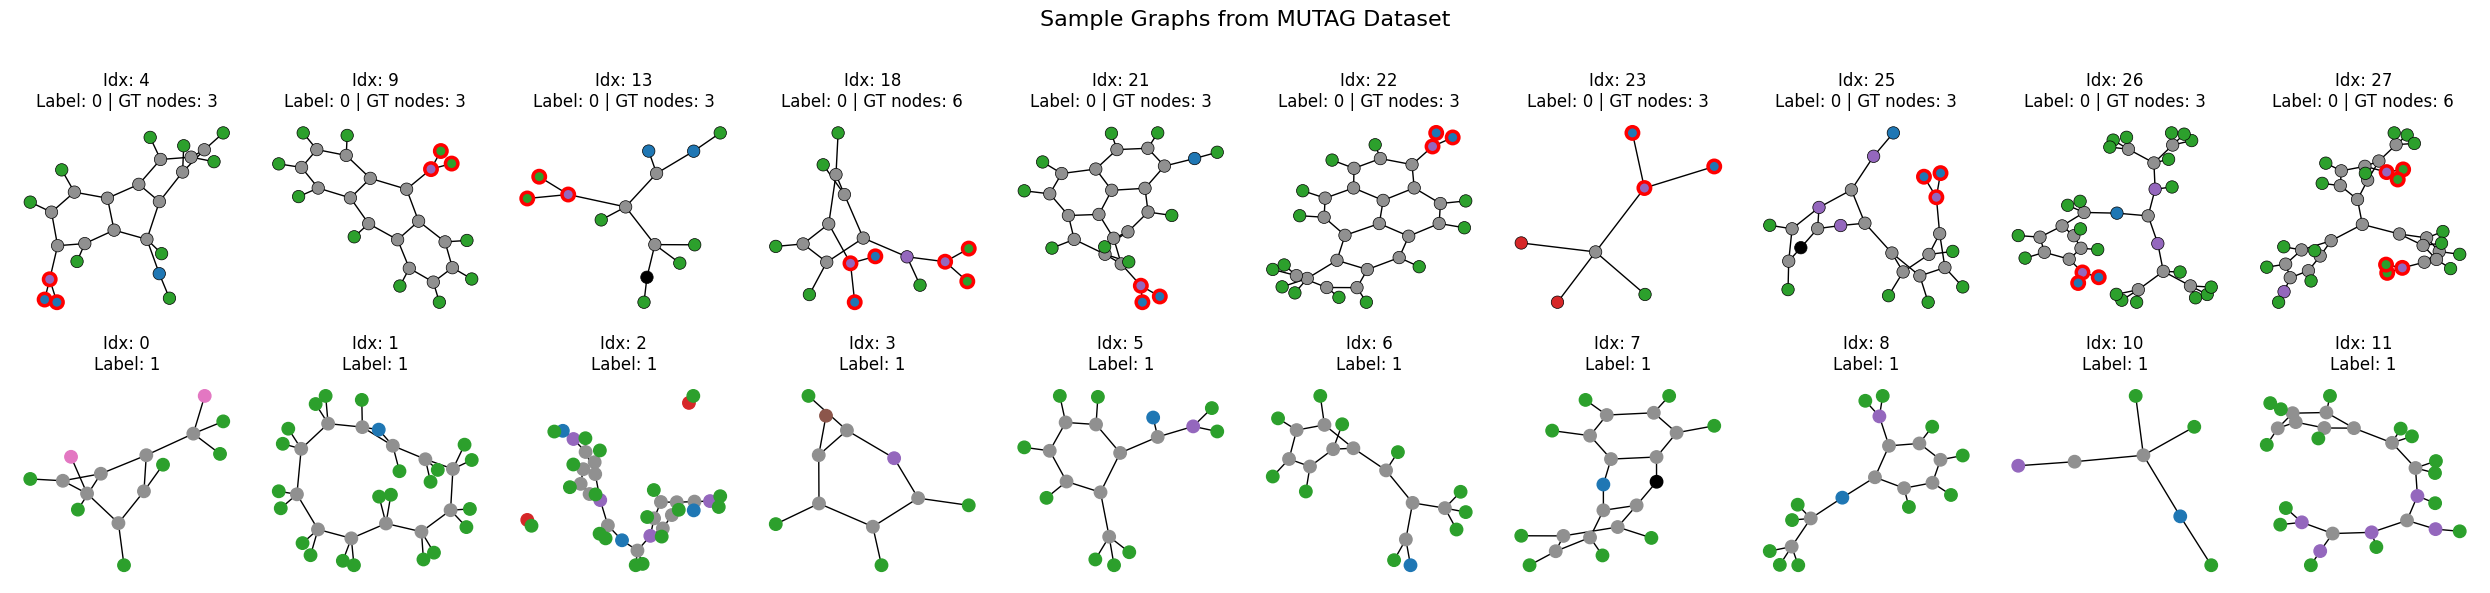

In [23]:
class_0_samples = []
class_1_samples = []

for i, data in enumerate(dataset):
    if data.y.item() == 0 and len(class_0_samples) < 10:
        class_0_samples.append((i, data))
    elif data.y.item() == 1 and len(class_1_samples) < 10:
        class_1_samples.append((i, data))
    
    if len(class_0_samples) == 10 and len(class_1_samples) == 10:
        break

# Atom colors for visualization
# C: Grey, N: Blue, O: Red, F: Green, I: Purple, Cl: Green, Br: Brown
atom_colors = ['#909090', '#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']

fig, axes = plt.subplots(2, 10, figsize=(25, 6))
fig.suptitle("Sample Graphs from MUTAG Dataset", fontsize=16)

def get_node_colors(data):
    # Find index of 1 in one-hot encoding
    atom_indices = data.x.argmax(dim=1).numpy()
    return [atom_colors[i] if i < len(atom_colors) else '#000000' for i in atom_indices]

def get_gt_mask(data):
    for name in ("explanation_mask", "node_mask", "node_gt_mask", "gt_node_mask"):
        if hasattr(data, name) and getattr(data, name) is not None:
            mask = getattr(data, name)
            if torch.is_tensor(mask):
                mask = mask.detach().cpu().numpy()
            return mask.astype(bool)
    return None

# Class 0 (Mutagenic) - highlight ground-truth motif nodes
for i, (original_index, data) in enumerate(class_0_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    ax = axes[0, i]
    pos = nx.spring_layout(g, seed=42)
    colors = get_node_colors(data)

    gt_mask = get_gt_mask(data)
    if gt_mask is not None and len(gt_mask) == data.num_nodes:
        node_edgecolors = ["red" if gt_mask[idx] else "black" for idx in range(data.num_nodes)]
        node_linewidths = [2.5 if gt_mask[idx] else 0.5 for idx in range(data.num_nodes)]
        gt_count = int(gt_mask.sum())
        title_suffix = f"GT nodes: {gt_count}"
    else:
        node_edgecolors = "black"
        node_linewidths = 0.5
        title_suffix = "GT nodes: n/a"

    nx.draw(
        g,
        pos,
        ax=ax,
        with_labels=False,
        node_size=80,
        node_color=colors,
        edgecolors=node_edgecolors,
        linewidths=node_linewidths,
    )
    ax.set_title(f"Idx: {original_index}\nLabel: 0 | {title_suffix}")

# Class 1 (Non-mutagenic)
for i, (original_index, data) in enumerate(class_1_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    ax = axes[1, i]
    pos = nx.spring_layout(g, seed=42)
    colors = get_node_colors(data)
    nx.draw(g, pos, ax=ax, with_labels=False, node_size=80, node_color=colors)
    ax.set_title(f"Idx: {original_index}\nLabel: 1")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Training Logic
We define the training and testing loops.

In [24]:
def train_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    optim.zero_grad()
    loss.backward()
    optim.step()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


@torch.inference_mode()
def test_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


def run_epoch(
    step_fn,
    model,
    data_loader,
    criterion,
    optim,
    step_metrics=None,
    epoch_metrics=None,
    ):
    epoch_metrics = epoch_metrics or {}
    for metric in epoch_metrics.values():
        metric.reset()
    epoch_info = {"steps": []}
    for step_index, batch in enumerate(data_loader):
        step_info = step_fn(model, batch, criterion, optim, step_metrics) | {
            "step_index": step_index
        }
        epoch_info["steps"].append(step_info)
        for metric in epoch_metrics.values():
            metric.update(step_info["pred"].squeeze(), batch.y)
    for name, metric in epoch_metrics.items():
        epoch_info[name] = metric.compute()
    return epoch_info


def train_and_test_model(
    model: PureBcosGINE,
    train_data: list,
    test_data: list,
    transform,
    num_train_epochs: int,
    lr: float,
    batch_size: int,
    ):
    if transform:
        train_data = [transform(d.clone()) for d in train_data]
        test_data = [transform(d.clone()) for d in test_data]

    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = BCEWithLogitsLoss()
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    train_epochs = [
        run_epoch(
            train_step,
            model,
            train_loader,
            criterion,
            optim,
            step_metrics=None,
            epoch_metrics={"accuracy": BinaryAccuracy()},
        )
        | {"epoch_index": epoch_index}
        for epoch_index in tqdm(
            range(num_train_epochs), f"Training {model.__class__.__name__}"
        )
    ]
    test_epoch = run_epoch(
        test_step,
        model,
        test_loader,
        criterion,
        optim,
        step_metrics=None,
        epoch_metrics={"accuracy": BinaryAccuracy()},
    )
    return train_epochs, test_epoch

## Model Training
We initialize the B-Cos GNN and train it on MUTAG.
MUTAG has 7 node features.

In [25]:
train_hyperparams = {
    "num_train_epochs": 100,
    "batch_size": 32, # Smaller batch size for smaller dataset
    "lr": 1e-3,
}

first_graph = dataset[0]
num_features = int(first_graph.x.shape[-1]) if hasattr(first_graph, "x") else int(first_graph.num_features)
edge_dim = int(first_graph.edge_attr.size(1)) if getattr(first_graph, "edge_attr", None) is not None else 1
print(f"Using node_size={num_features}, edge_dim={edge_dim}")

best_hyperparams = {
    "node_dim": num_features,
    "edge_dim": edge_dim,
    "hidden_dim": 64,
    "num_layers": 3,
    "num_classes": 1,
    "b": 2,
    "max_out": 1,
    "dropout": 0.5,
}

best_model = PureBcosGINE(**best_hyperparams)

# No transform needed if features are already present
transform = None 

train_epochs, test_epoch = train_and_test_model(
    model=best_model,
    train_data=train_dataset,
    test_data=test_dataset,
    transform=transform,
    **train_hyperparams,
)

print(f"Best model test accuracy: {test_epoch['accuracy']:.4f}")

Using node_size=14, edge_dim=3


Training PureBcosGINE: 100%|██████████| 100/100 [00:38<00:00,  2.62it/s]

Best model test accuracy: 0.9335


## Explanation and Visualization
We visualize the explanations for mutagenic compounds (Class 0).
We look for high importance on Carbon rings with $NO_2$ or $NH_2$ groups.
We use the `bcosgnn.evaluation` module for attribution.

### Explainability Metrics (BCOS GINE)
We compute node-level AUROC and Jaccard@5 using ground-truth node masks in the `.pt` dataset.

In [26]:
from sklearn.metrics import roc_auc_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _get_node_mask(data):
    for name in ("explanation_mask", "node_mask", "node_gt_mask", "gt_node_mask"):
        if hasattr(data, name) and getattr(data, name) is not None:
            mask = getattr(data, name)
            return mask.detach().cpu().numpy().astype(int)
    return None

def node_scores_from_contrib(x_contrib: torch.Tensor) -> np.ndarray:
    return x_contrib.abs().sum(dim=-1).detach().cpu().numpy()

def jaccard_at_k(scores: np.ndarray, gt_mask: np.ndarray, k: int) -> float:
    if k <= 0:
        return float("nan")
    top_idx = np.argsort(scores)[-k:]
    pred = np.zeros_like(gt_mask, dtype=bool)
    pred[top_idx] = True
    gt = gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union > 0 else float("nan")

# Ensure model is on device
best_model = best_model.to(DEVICE)
best_model.eval()

TOP_K = 5

aurocs = []
jaccs = []

for d in test_dataset:
    gt = _get_node_mask(d)
    if gt is None:
        continue
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        _ = best_model(d.x, d.edge_index, d.edge_attr, d.batch)

    contrib = explain_edge_attr(
        best_model,
        d.x,
        d.edge_index,
        d.edge_attr,
        d.batch,
        target=None,
    )

    scores = node_scores_from_contrib(contrib["x"])

    if gt.min() != gt.max():
        aurocs.append(roc_auc_score(gt, scores))

    if TOP_K > 0:
        jaccs.append(jaccard_at_k(scores, gt, TOP_K))

if aurocs:
    print(f"Node AUROC@all: mean={np.mean(aurocs):.4f} ± {np.std(aurocs, ddof=1) if len(aurocs)>1 else 0.0:.4f} (n={len(aurocs)})")
else:
    print("Node AUROC: n=0 (no non-degenerate ground-truth masks found)")

if jaccs:
    print(f"Jaccard@{TOP_K}: mean={np.mean(jaccs):.4f} ± {np.std(jaccs, ddof=1) if len(jaccs)>1 else 0.0:.4f} (n={len(jaccs)})")
else:
    print(f"Jaccard@{TOP_K}: n=0 (no valid ground-truth masks)")

Node AUROC@all: mean=0.8835 ± 0.1514 (n=241)
Jaccard@5: mean=0.2893 ± 0.2926 (n=406)


In [ ]:
from sklearn.metrics import f1_score

def find_optimal_threshold(model, dataset):
    y_true = []
    y_scores = []
    
    model.eval()
    with torch.no_grad():
        for data in dataset:
            batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
            out = model(data.x, data.edge_index, data.edge_attr, batch)
            y_true.append(data.y.item())
            y_scores.append(out.item())
            
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # Check F1 score for a range of thresholds
    # We scan from min to max logit
    thresholds = np.linspace(y_scores.min(), y_scores.max(), 100)
    best_f1 = 0
    best_thresh = 0.0
    
    for thresh in thresholds:
        y_pred = (y_scores > thresh).astype(int)
        # Use 'binary' average for Class 0 (Mutagenic)
        f1 = f1_score(y_true, y_pred, average='binary')
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            
    return best_thresh, best_f1

optimal_threshold, best_f1 = find_optimal_threshold(best_model, test_dataset)
print(f"Optimal Threshold (Logit): {optimal_threshold:.4f}")
print(f"Best F1 Score on Test Set: {best_f1:.4f}")

Optimal Threshold (Logit): 0.6629
Best F1 Score on Test Set: 0.8980


In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score, precision_recall_curve
from torch_geometric.loader import DataLoader

# --- 1. Helper Function: Find Optimal Threshold & F1 ---
def compute_optimal_f1(y_true, y_logits):
    """
    Computes the best F1 score by searching for the optimal classification threshold.
    """
    # Convert logits to probabilities
    y_probs = torch.sigmoid(torch.tensor(y_logits)).numpy()
    
    # Get precision, recall, and thresholds from sklearn
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Calculate F1 for every threshold provided by the curve
    # Note: precision_recall_curve returns one more precision/recall value than thresholds
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # The last F1 score corresponds to a threshold of 1.0 (usually 0 recall), drop it or handle it
    f1_scores = f1_scores[:-1]
    
    # Find the best index
    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]
    best_thresh = thresholds[best_idx]
    
    # Calculate accuracy at this specific threshold for consistency
    y_pred_optimal = (y_probs >= best_thresh).astype(int)
    best_acc = accuracy_score(y_true, y_pred_optimal)
    
    return best_f1, best_acc, best_thresh

# --- 2. Training & Evaluation Functions ---

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        # MUTAG is binary; assuming BCEWithLogitsLoss logic 
        # (Output dim 1 or 2? Based on your notebook usually dim 2 for CrossEntropy or 1 for BCE)
        # If model outputs 2 classes, we take the logit diff or specific class logit for thresholding.
        # Let's assume standard CrossEntropy (2 outputs) -> take logit for class 1 - logit class 0
        if out.shape[1] > 1:
            loss = criterion(out, data.y)
        else:
            loss = criterion(out.flatten(), data.y.float())
            
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_optimal(model, loader, device):
    model.eval()
    y_true, y_logits = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        # Handle Output shape for logits
        if out.shape[1] > 1:
            # For 2-class output, prob = softmax. We simulate logit for class 1 by (class1 - class0)
            # or just taking class 1 score if using softmax later. 
            # For threshold search, simpler to use (Logit_1 - Logit_0)
            score = out[:, 1] - out[:, 0]
        else:
            score = out.flatten()
            
        y_true.extend(data.y.cpu().numpy())
        y_logits.extend(score.cpu().numpy())
    
    # Compute metrics using the optimal threshold finder
    return compute_optimal_f1(y_true, y_logits)

# --- 3. Main Experiment Loop (5 Seeds) ---

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seeds = [42, 123, 999, 7, 2024]

# Hyperparams from your notebook context
HIDDEN_DIM = 64
NUM_LAYERS = 3
DROPOUT = 0.5
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 64

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

results = {"f1": [], "acc": [], "thresh": []}

print(f"--- Running Bcos GINE (Optimal Threshold Search) ---")

for seed in seeds:
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Initialize Model (PureBcosGINE as defined in your notebook)
    model = PureBcosGINE(
        node_dim=dataset.num_features,
        edge_dim=dataset.edge_attr.shape[1],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        b = 2,
        max_out = 1,
        num_classes=dataset.num_classes,
        dropout=DROPOUT
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_seed_f1 = 0.0
    best_seed_acc = 0.0
    best_seed_thresh = 0.0

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        

        f1, acc, thresh = evaluate_optimal(model, test_loader, device)
        
        if f1 > best_seed_f1:
            best_seed_f1 = f1
            best_seed_acc = acc
            best_seed_thresh = thresh

    results["f1"].append(best_seed_f1)
    results["acc"].append(best_seed_acc)
    results["thresh"].append(best_seed_thresh)
    
    print(f"Seed {seed}: Best F1: {best_seed_f1:.4f} (Acc: {best_seed_acc:.4f}) @ Thresh: {best_seed_thresh:.3f}")

# --- 4. Final Report ---
print("\n=== Final Results (5 Seeds) ===")
print(f"Mean Optimal F1: {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"Mean Accuracy:   {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")

--- Running Bcos GINE (Optimal Threshold Search) ---
Seed 42: Best F1: 0.9388 (Acc: 0.9211) @ Thresh: 0.786
Seed 123: Best F1: 0.9231 (Acc: 0.8947) @ Thresh: 0.644
Seed 999: Best F1: 0.8980 (Acc: 0.8684) @ Thresh: 0.694
Seed 7: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.508
Seed 2024: Best F1: 0.9020 (Acc: 0.8684) @ Thresh: 0.881

=== Final Results (5 Seeds) ===
Mean Optimal F1: 0.9164 ± 0.0149
Mean Accuracy:   0.8895 ± 0.0197


In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_recall_curve
from torch_geometric.nn import GINEConv, global_add_pool
from torch_geometric.loader import DataLoader

# --- 1. Vanilla GINE Model Definition ---
class VanillaGINE(torch.nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim=64, num_layers=4, num_classes=2, dropout=0.5):
        super().__init__()
        
        # Initial projection of features
        self.lin_node = nn.Linear(node_dim, hidden_dim)
        self.lin_edge = nn.Linear(edge_dim, hidden_dim)
        
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            # Standard GIN uses an MLP inside the convolution
            # Structure: Linear -> ReLU -> Linear
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINEConv(nn=mlp, train_eps=True))
            
        # Classifier Head (matches the Bcos readout logic usually)
        self.dropout_p = dropout
        self.post_conv = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x, edge_index, edge_attr, batch):
        # 1. Embed Inputs
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        
        # 2. Message Passing
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x) # Non-linearity between GNN layers
        
        # 3. Global Pooling (Sum pooling is standard for GIN/Bcos)
        x = global_add_pool(x, batch)
        
        # 4. Classification
        return self.post_conv(x)

# --- 2. Helper: Optimal Threshold Finder ---
def compute_optimal_f1(y_true, y_logits):
    """
    Computes best F1 by sweeping through thresholds on the provided logits.
    """
    y_probs = torch.sigmoid(torch.tensor(y_logits)).numpy()
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # F1 = 2 * (P * R) / (P + R)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    # precision_recall_curve returns one extra value for 1.0 threshold
    f1_scores = f1_scores[:-1]
    
    if len(f1_scores) == 0:
        return 0.0, 0.0, 0.5

    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]
    best_thresh = thresholds[best_idx]
    
    # Calculate Accuracy at this specific threshold
    y_pred_optimal = (y_probs >= best_thresh).astype(int)
    best_acc = accuracy_score(y_true, y_pred_optimal)
    
    return best_f1, best_acc, best_thresh

# --- 3. Training & Eval Functions ---
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_optimal(model, loader, device):
    model.eval()
    y_true, y_logits = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        # For CrossEntropy (2 outputs), we use (Class 1 Logit - Class 0 Logit)
        # to get a single scalar score for thresholding
        score = out[:, 1] - out[:, 0]
        
        y_true.extend(data.y.cpu().numpy())
        y_logits.extend(score.cpu().numpy())
    
    return compute_optimal_f1(y_true, y_logits)

# --- 4. Main Experiment Loop (5 Seeds) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seeds = [42, 123, 999, 7, 2024]

# Hyperparameters (Matched to Notebook)
HIDDEN_DIM = 64
NUM_LAYERS = 3
DROPOUT = 0.5
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 64

# Re-initialize loaders (assuming train_dataset/test_dataset exist from previous cells)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

vanilla_results = {"f1": [], "acc": [], "thresh": []}

print(f"--- Running Vanilla GINE (Optimal Threshold Search) ---")

for seed in seeds:
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Initialize Vanilla GINE
    model = VanillaGINE(
        node_dim=dataset.num_features,
        edge_dim=dataset.edge_attr.shape[1],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=dataset.num_classes,
        dropout=DROPOUT
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_seed_f1 = 0.0
    best_seed_acc = 0.0
    best_seed_thresh = 0.0

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        
        # Check Test performance with optimal threshold
        f1, acc, thresh = evaluate_optimal(model, test_loader, device)
        
        if f1 > best_seed_f1:
            best_seed_f1 = f1
            best_seed_acc = acc
            best_seed_thresh = thresh

    vanilla_results["f1"].append(best_seed_f1)
    vanilla_results["acc"].append(best_seed_acc)
    vanilla_results["thresh"].append(best_seed_thresh)
    
    print(f"Seed {seed}: Best F1: {best_seed_f1:.4f} (Acc: {best_seed_acc:.4f}) @ Thresh: {best_seed_thresh:.3f}")

# --- 5. Final Report ---
print("\n=== Vanilla GINE Final Results (5 Seeds) ===")
print(f"Mean Optimal F1: {np.mean(vanilla_results['f1']):.4f} ± {np.std(vanilla_results['f1']):.4f}")
print(f"Mean Accuracy:   {np.mean(vanilla_results['acc']):.4f} ± {np.std(vanilla_results['acc']):.4f}")

--- Running Vanilla GINE (Optimal Threshold Search) ---
Seed 42: Best F1: 0.9412 (Acc: 0.9211) @ Thresh: 0.386
Seed 42: Best F1: 0.9412 (Acc: 0.9211) @ Thresh: 0.386
Seed 123: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.796
Seed 123: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.796
Seed 999: Best F1: 0.9259 (Acc: 0.8947) @ Thresh: 0.210
Seed 999: Best F1: 0.9259 (Acc: 0.8947) @ Thresh: 0.210
Seed 7: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.763
Seed 7: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.763
Seed 2024: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.752

=== Vanilla GINE Final Results (5 Seeds) ===
Mean Optimal F1: 0.9254 ± 0.0082
Mean Accuracy:   0.9000 ± 0.0105
Seed 2024: Best F1: 0.9200 (Acc: 0.8947) @ Thresh: 0.752

=== Vanilla GINE Final Results (5 Seeds) ===
Mean Optimal F1: 0.9254 ± 0.0082
Mean Accuracy:   0.9000 ± 0.0105


In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score
from torch_geometric.nn import GINEConv, global_add_pool
from torch_geometric.loader import DataLoader

# ==========================================
# 1. SHARED SETUP & HELPER FUNCTIONS
# ==========================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seeds = [42, 123, 999, 7, 2024]

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 3
DROPOUT = 0.5
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 64

# Standard Training Loop
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

# Standard Evaluation (ARGMAX)
# This replaces the "optimal threshold" logic with standard classification
@torch.no_grad()
def evaluate_standard(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        
        # Standard Decision: Class with highest score
        pred = out.argmax(dim=1)
        
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
    
    acc = accuracy_score(y_true, y_pred)
    # Macro F1 is standard for imbalanced datasets (treats both classes equally)
    f1 = f1_score(y_true, y_pred, average='macro')
    return f1, acc

# Loaders (Ensuring clean start)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 2. EXPERIMENT 1: BCOS GINE
# ==========================================
bcos_results = {"f1": [], "acc": []}

print(f"--- Running Bcos GINE (Standard Argmax) ---")

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Initialize PureBcosGINE (from your notebook context)
    model = PureBcosGINE(
        node_dim=dataset.num_features,
        edge_dim=dataset.edge_attr.shape[1],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=dataset.num_classes,
        dropout=DROPOUT,
        b=3.0,
        max_out=1
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0
    best_acc = 0
    
    for epoch in range(EPOCHS):
        _ = train_one_epoch(model, train_loader, optimizer, criterion, device)
        f1, acc = evaluate_standard(model, test_loader, device)
        
        if f1 > best_f1:
            best_f1 = f1
            best_acc = acc

    bcos_results["f1"].append(best_f1)
    bcos_results["acc"].append(best_acc)
    print(f"Seed {seed}: F1={best_f1:.4f} Acc={best_acc:.4f}")

# ==========================================
# 3. EXPERIMENT 2: VANILLA GINE
# ==========================================
# Define Vanilla Class locally to ensure it exists
class VanillaGINE(torch.nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.lin_node = nn.Linear(node_dim, hidden_dim)
        self.lin_edge = nn.Linear(edge_dim, hidden_dim)
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINEConv(mlp, train_eps=True))
        self.post_conv = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x, edge_index, edge_attr, batch):
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = torch.relu(x)
        x = global_add_pool(x, batch)
        return self.post_conv(x)

vanilla_results = {"f1": [], "acc": []}

print(f"\n--- Running Vanilla GINE (Standard Argmax) ---")

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = VanillaGINE(
        node_dim=dataset.num_features,
        edge_dim=dataset.edge_attr.shape[1],
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=dataset.num_classes,
        dropout=DROPOUT
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0
    best_acc = 0
    
    for epoch in range(EPOCHS):
        _ = train_one_epoch(model, train_loader, optimizer, criterion, device)
        f1, acc = evaluate_standard(model, test_loader, device)
        
        if f1 > best_f1:
            best_f1 = f1
            best_acc = acc

    vanilla_results["f1"].append(best_f1)
    vanilla_results["acc"].append(best_acc)
    print(f"Seed {seed}: F1={best_f1:.4f} Acc={best_acc:.4f}")

# ==========================================
# 4. FINAL COMPARISON
# ==========================================
print("\n====== FINAL RESULTS (Standard Evaluation) ======")
print(f"Bcos GINE    | F1: {np.mean(bcos_results['f1']):.4f} ± {np.std(bcos_results['f1']):.4f} | Acc: {np.mean(bcos_results['acc']):.4f} ± {np.std(bcos_results['acc']):.4f}")
print(f"Vanilla GINE | F1: {np.mean(vanilla_results['f1']):.4f} ± {np.std(vanilla_results['f1']):.4f} | Acc: {np.mean(vanilla_results['acc']):.4f} ± {np.std(vanilla_results['acc']):.4f}")

--- Running Bcos GINE (Standard Argmax) ---
Seed 42: F1=0.7818 Acc=0.8158
Seed 123: F1=0.7662 Acc=0.7895
Seed 999: F1=0.8246 Acc=0.8421
Seed 7: F1=0.7564 Acc=0.7895
Seed 2024: F1=0.7662 Acc=0.7895

--- Running Vanilla GINE (Standard Argmax) ---
Seed 42: F1=0.8869 Acc=0.8947
Seed 123: F1=0.8638 Acc=0.8684
Seed 999: F1=0.8348 Acc=0.8421
Seed 7: F1=0.8564 Acc=0.8684
Seed 2024: F1=0.8048 Acc=0.8158

====== FINAL RESULTS (Standard Evaluation) ======
Bcos GINE    | F1: 0.7790 ± 0.0242 | Acc: 0.8053 ± 0.0211
Vanilla GINE | F1: 0.8493 ± 0.0278 | Acc: 0.8579 ± 0.0268


In [29]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_explanation(graph, node_importance=None, edge_importance=None, top_k=5, title=None):
    """
    Visualize a graph with node and/or edge importance scores.
    Highlights top_k nodes/edges by importance.
    graph: networkx.Graph or torch_geometric.data.Data
    node_importance: np.ndarray or list, shape (num_nodes,)
    edge_importance: np.ndarray or list, shape (num_edges,)
    top_k: int, number of top nodes/edges to highlight
    title: str, plot title
    """
    if hasattr(graph, 'to_networkx'):
        G = graph.to_networkx()
    else:
        G = graph
    pos = nx.spring_layout(G, seed=42)
    node_color = 'lightgray'
    edge_color = 'gray'
    node_sizes = 300
    edge_widths = 1
    
    if node_importance is not None:
        node_importance = np.array(node_importance)
        top_nodes = node_importance.argsort()[-top_k:][::-1]
        node_colors = ["red" if i in top_nodes else node_color for i in range(G.number_of_nodes())]
        node_sizes = [600 if i in top_nodes else 300 for i in range(G.number_of_nodes())]
    else:
        node_colors = node_color
        node_sizes = 300
    
    if edge_importance is not None:
        edge_importance = np.array(edge_importance)
        top_edges = edge_importance.argsort()[-top_k:][::-1]
        edge_colors = []
        edge_widths = []
        for idx, e in enumerate(G.edges()):
            if idx in top_edges:
                edge_colors.append("red")
                edge_widths.append(3)
            else:
                edge_colors.append(edge_color)
                edge_widths.append(1)
    else:
        edge_colors = edge_color
        edge_widths = 1
    
    plt.figure(figsize=(6, 6))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes,
            edge_color=edge_colors, width=edge_widths, font_weight='bold')
    if title:
        plt.title(title)
    plt.show()

# Example usage:
# visualize_explanation(graph, node_importance=attributions, top_k=5, title="Top-5 Node Explanations")

In [27]:
import numpy as np

def dynamic_jaccard_at_k(preds, targets):
    """
    preds: np.ndarray, shape (N, num_items), prediction scores
    targets: np.ndarray, shape (N, num_items), binary ground truth
    Returns: list of Jaccard@k for each sample
    """
    jaccards = []
    for pred, target in zip(preds, targets):
        k = int(target.sum())
        if k == 0:
            jaccards.append(float('nan'))
            continue
        topk_idx = pred.argsort()[-k:][::-1]
        pred_set = set(topk_idx)
        true_set = set(np.where(target)[0])
        intersection = len(pred_set & true_set)
        union = len(pred_set | true_set)
        jaccards.append(intersection / union if union > 0 else 0.0)
    return jaccards

# Example usage:
# preds = np.array([[0.1, 0.8, 0.3], [0.5, 0.2, 0.9]])
# targets = np.array([[0, 1, 1], [1, 0, 1]])
# jaccard_scores = dynamic_jaccard_at_k(preds, targets)
# print(jaccard_scores)

## Dynamic K Jaccard@k and Explanation Visualization

This section implements a dynamic K strategy for Jaccard@k (where $k$ is set per-sample to the number of ground truth positives), and provides code to visualize explanations (e.g., top-k node/edge attributions).

In [28]:
import numpy as np
import torch

# Ensure the model is in eval mode and on the correct device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = best_model.to(DEVICE)
best_model.eval()

all_preds = []
all_targets = []

print("Extracting attributions and ground truth masks for the test set...")
for d in test_dataset:
    gt = _get_node_mask(d)
    
    # Skip graphs that do not have a ground-truth explanation mask
    if gt is None:
        continue
        
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    # Forward pass
    with torch.no_grad():
        _ = best_model(d.x, d.edge_index, d.edge_attr, d.batch)

    # Generate explanations
    contrib = explain_edge_attr(
        best_model,
        d.x,
        d.edge_index,
        d.edge_attr,
        d.batch,
        target=None,
    )

    # Extract node importance scores from contributions
    scores = node_scores_from_contrib(contrib["x"])

    all_preds.append(scores)
    all_targets.append(gt)

# Calculate dynamic Jaccard@k using the lists of arrays
jaccard_scores = dynamic_jaccard_at_k(all_preds, all_targets)

# Filter out NaNs (which occur if a graph has a ground truth mask but k=0 positives)
valid_jaccards = [score for score in jaccard_scores if not np.isnan(score)]

if valid_jaccards:
    mean_jaccard = np.mean(valid_jaccards)
    std_jaccard = np.std(valid_jaccards, ddof=1) if len(valid_jaccards) > 1 else 0.0
    print(f"\nDynamic Jaccard@k: mean={mean_jaccard:.4f} ± {std_jaccard:.4f} (n={len(valid_jaccards)})")
else:
    print("\nDynamic Jaccard@k: n=0 (no valid ground-truth masks found)")

Extracting attributions and ground truth masks for the test set...

Dynamic Jaccard@k: mean=0.6516 ± 0.3144 (n=241)

Dynamic Jaccard@k: mean=0.6516 ± 0.3144 (n=241)


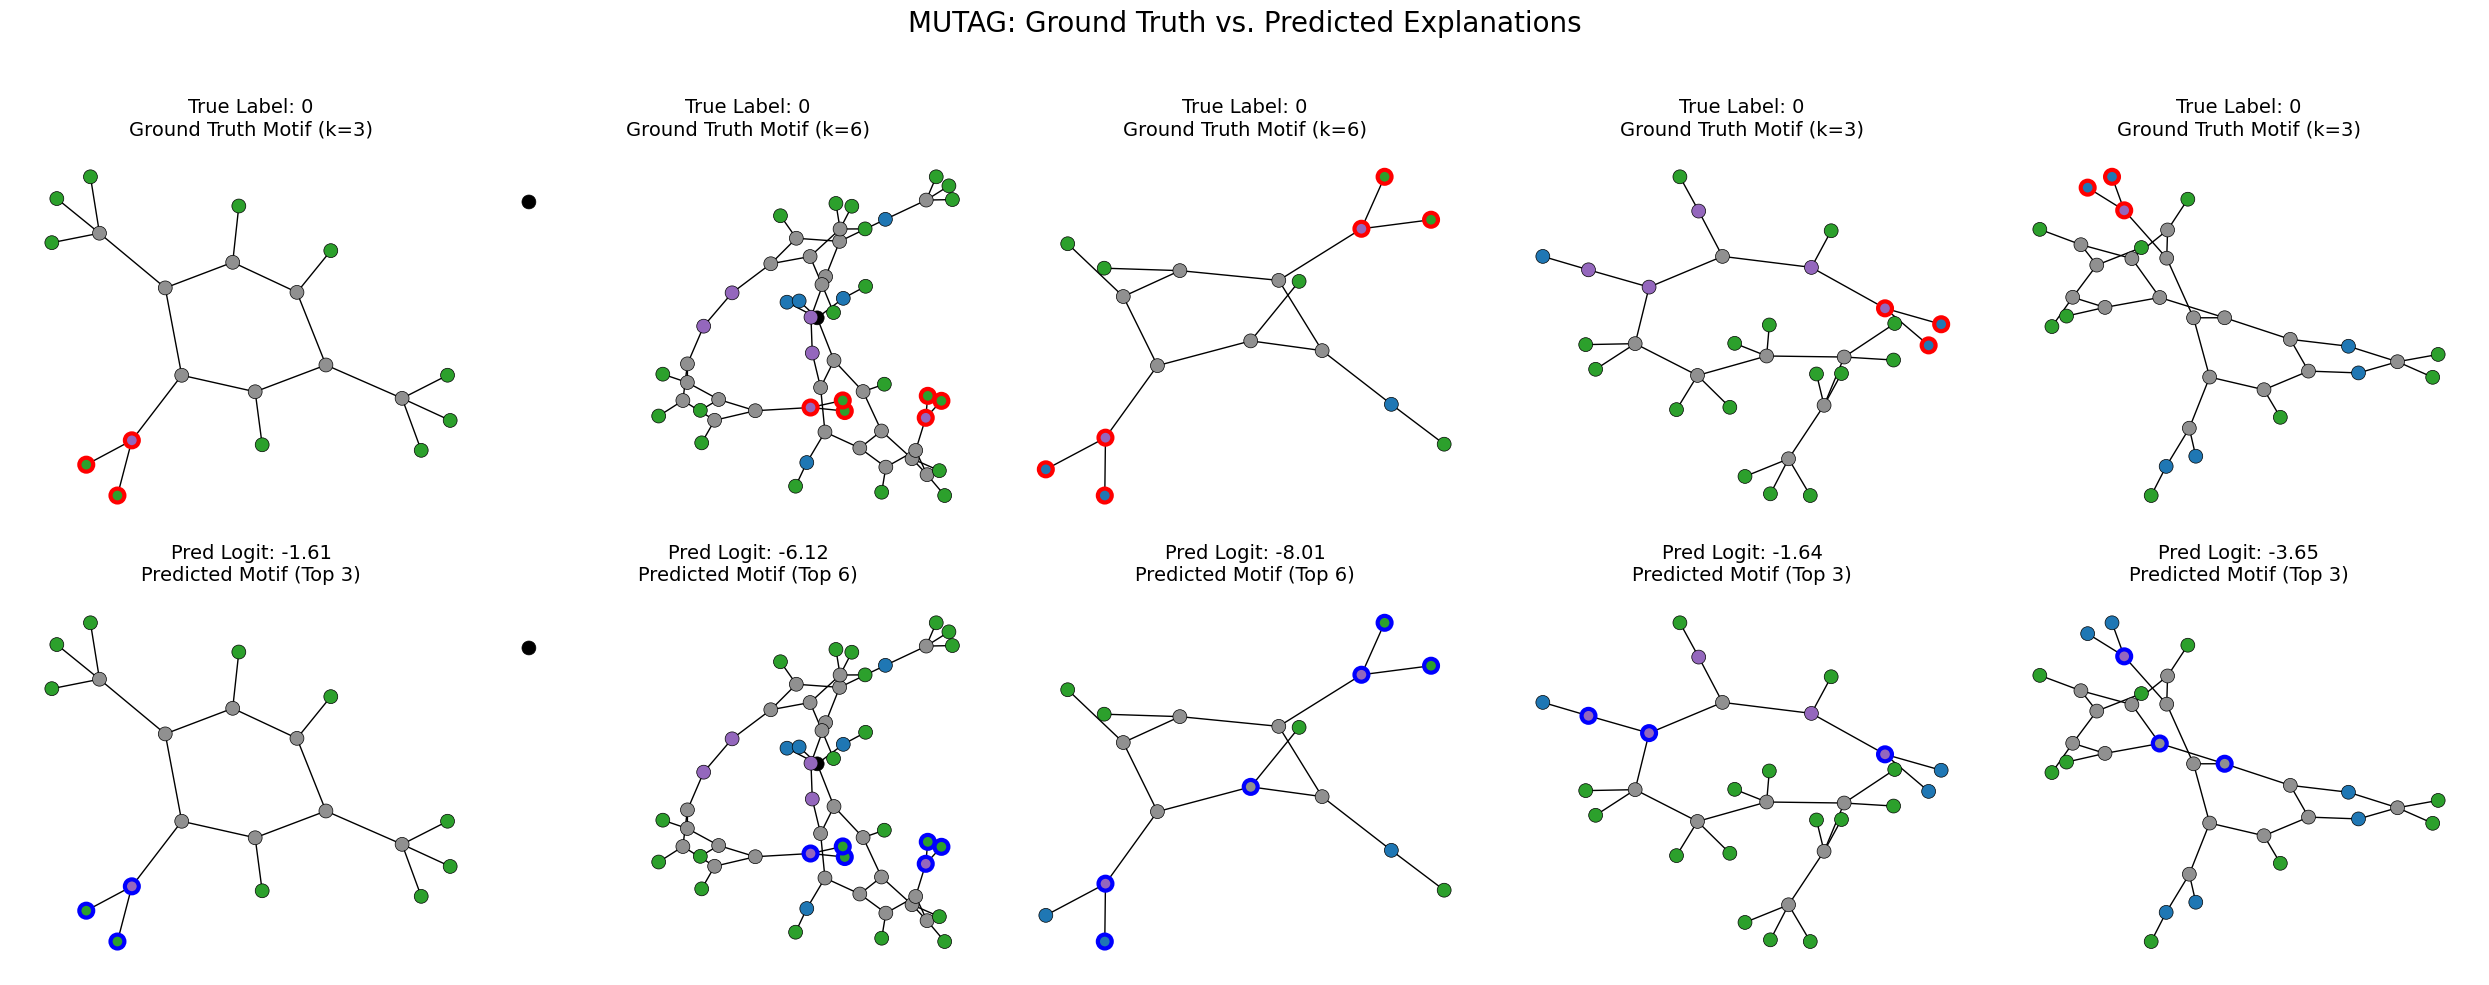

In [30]:
import matplotlib.pyplot as plt
import networkx as nx
import torch

# Ensure model is on the right device and in eval mode
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = best_model.to(DEVICE)
best_model.eval()

# 1. Select 5 sample graphs from the test set that have ground truth masks (Class 0)
sample_graphs = []
for d in test_dataset:
    if _get_node_mask(d) is not None and d.y.item() == 0:
        sample_graphs.append(d)
    if len(sample_graphs) == 5:
        break

# 2. Set up the matplotlib figure (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle("MUTAG: Ground Truth vs. Predicted Explanations", fontsize=20)

for i, data in enumerate(sample_graphs):
    d = data.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)
    
    # Get ground truth mask and label
    gt_mask = _get_node_mask(d)
    true_label = d.y.item()
    
    # 3. Model Prediction & Explanation
    with torch.no_grad():
        out = best_model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred_logit = out.item()
        
    contrib = explain_edge_attr(
        best_model, d.x, d.edge_index, d.edge_attr, d.batch, target=None
    )
    scores = node_scores_from_contrib(contrib["x"])
    
    # Create NetworkX graph for plotting
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    pos = nx.spring_layout(g, seed=42)
    base_colors = get_node_colors(data) # Using your existing atom color mapping
    
    # ==========================================
    # Row 0: Ground Truth
    # ==========================================
    ax_gt = axes[0, i]
    if gt_mask is not None:
        # Highlight ground truth nodes with thick red borders
        node_edgecolors_gt = ["red" if m else "black" for m in gt_mask]
        node_linewidths_gt = [3.0 if m else 0.5 for m in gt_mask]
        gt_k = int(gt_mask.sum())
    else:
        node_edgecolors_gt = "black"
        node_linewidths_gt = 0.5
        gt_k = 0
        
    nx.draw(g, pos, ax=ax_gt, with_labels=False, node_size=100, 
            node_color=base_colors, edgecolors=node_edgecolors_gt, linewidths=node_linewidths_gt)
    ax_gt.set_title(f"True Label: {true_label}\nGround Truth Motif (k={gt_k})", fontsize=14)

    # ==========================================
    # Row 1: Predicted Motif
    # ==========================================
    ax_pred = axes[1, i]
    
    # Dynamic K: Highlight the top K nodes based on attribution scores, 
    # where K matches the size of the ground truth motif
    top_idx = scores.argsort()[-gt_k:][::-1] if gt_k > 0 else []
    
    # Highlight predicted nodes with thick blue borders
    node_edgecolors_pred = ["blue" if idx in top_idx else "black" for idx in range(data.num_nodes)]
    node_linewidths_pred = [3.0 if idx in top_idx else 0.5 for idx in range(data.num_nodes)]
    
    nx.draw(g, pos, ax=ax_pred, with_labels=False, node_size=100, 
            node_color=base_colors, edgecolors=node_edgecolors_pred, linewidths=node_linewidths_pred)
    
    # Display the predicted logit (using your earlier threshold code, < 0.66 usually means class 0/mutagenic)
    ax_pred.set_title(f"Pred Logit: {pred_logit:.2f}\nPredicted Motif (Top {gt_k})", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Node AUROC: Mean = 0.8835 ± 0.1514 (n=241)



[17:23:34] Explicit valence for atom # 3 N, 4, is greater than permitted
[17:23:34] Explicit valence for atom # 8 N, 4, is greater than permitted
[17:23:34] Explicit valence for atom # 13 N, 4, is greater than permitted
[17:23:34] Explicit valence for atom # 3 N, 4, is greater than permitted
[17:23:34] Explicit valence for atom # 8 N, 4, is greater than permitted
[17:23:34] Explicit valence for atom # 13 N, 4, is greater than permitted


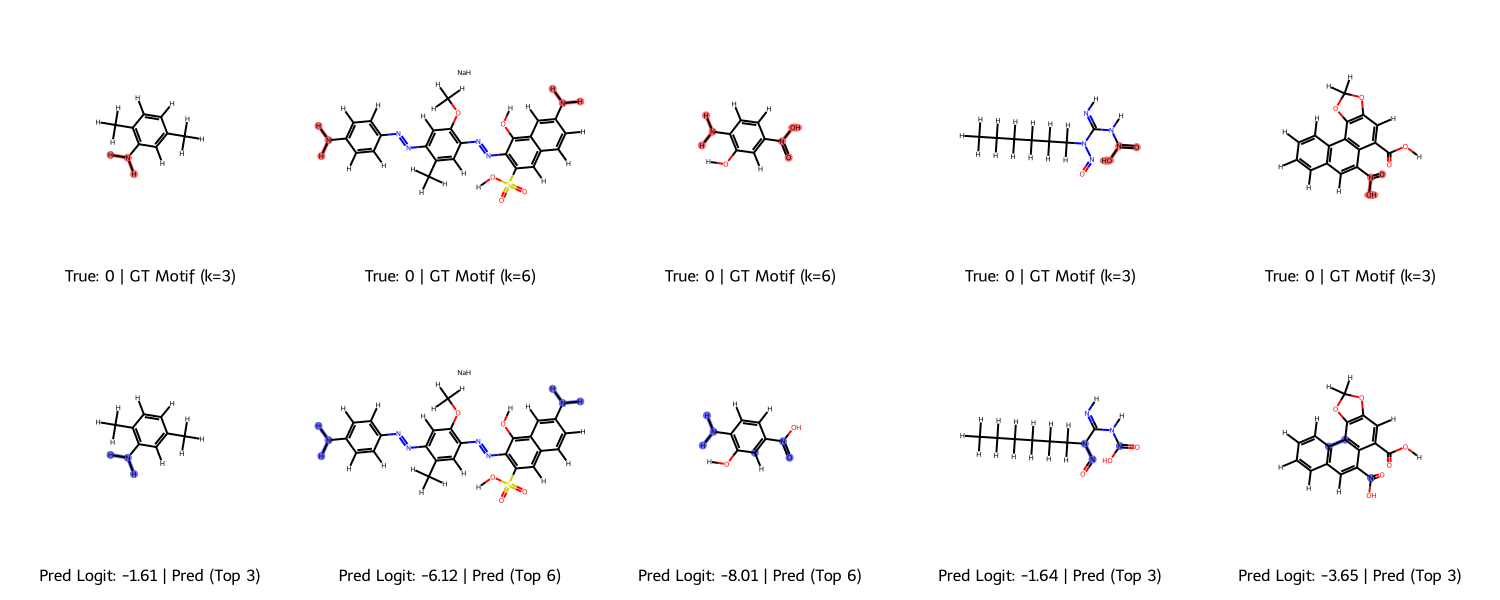

In [31]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor

# Ensure model is on the right device and in eval mode
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = best_model.to(DEVICE)
best_model.eval()

# ==========================================
# 1. Calculate AUROC Score
# ==========================================
aurocs = []

for d in test_dataset:
    gt = _get_node_mask(d)
    
    # Skip graphs that do not have a mask or have all 0s/1s (AUROC undefined)
    if gt is None or gt.min() == gt.max():
        continue
        
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        _ = best_model(d.x, d.edge_index, d.edge_attr, d.batch)

    contrib = explain_edge_attr(
        best_model, d.x, d.edge_index, d.edge_attr, d.batch, target=None
    )
    scores = node_scores_from_contrib(contrib["x"])
    
    # Node-level AUROC for this graph
    aurocs.append(roc_auc_score(gt, scores))

if aurocs:
    print(f"Node AUROC: Mean = {np.mean(aurocs):.4f} ± {np.std(aurocs, ddof=1):.4f} (n={len(aurocs)})\n")
else:
    print("Node AUROC: n=0 (No valid non-degenerate ground-truth masks found)\n")

# ==========================================
# 2. RDKit PyG to Mol Converter
# ==========================================
# Your specific atom mapping
ATOM_MAP = {
    0: 'C', 1: 'O', 2: 'Cl', 3: 'H', 4: 'N', 5: 'F', 
    6: 'Br', 7: 'S', 8: 'P', 9: 'I', 10: 'Na', 11: 'K', 12: 'Li', 13: 'Ca'
}

def pyg_to_rdkit(data):
    mol = Chem.RWMol()
    node_types = data.x.argmax(dim=1).cpu().numpy()
    
    # Add atoms
    for nt in node_types:
        symbol = ATOM_MAP.get(nt, 'C') # Default to C if out of bounds
        mol.AddAtom(Chem.Atom(symbol))
        
    # Add edges (PyG is directed/bidirectional, we need undirected for RDKit)
    added_edges = set()
    edges = data.edge_index.t().cpu().numpy()
    
    # Safely handle edge attributes if they exist (assuming one-hot encoded: Single, Double, Aromatic, etc.)
    if hasattr(data, 'edge_attr') and data.edge_attr is not None:
        edge_attrs = data.edge_attr.argmax(dim=1).cpu().numpy()
    else:
        edge_attrs = [0] * len(edges)
        
    for e_idx, (u, v) in enumerate(edges):
        if u < v and (u, v) not in added_edges:
            # Map edge attributes to RDKit bond types (Fallback to SINGLE)
            bond_type = Chem.rdchem.BondType.SINGLE
            if edge_attrs[e_idx] == 1: 
                bond_type = Chem.rdchem.BondType.DOUBLE
            elif edge_attrs[e_idx] == 2: 
                bond_type = Chem.rdchem.BondType.AROMATIC
            elif edge_attrs[e_idx] == 3: 
                bond_type = Chem.rdchem.BondType.TRIPLE
                
            mol.AddBond(int(u), int(v), bond_type)
            added_edges.add((u, v))
            
    # Compute 2D coordinates for plotting
    Chem.SanitizeMol(mol, catchErrors=True)
    rdDepictor.Compute2DCoords(mol)
    return mol.GetMol()

# ==========================================
# 3. Generate RDKit Visualization
# ==========================================
# Select 5 sample graphs from Class 0 (which have GT masks)
sample_graphs = []
for d in test_dataset:
    if _get_node_mask(d) is not None and d.y.item() == 0:
        sample_graphs.append(d)
    if len(sample_graphs) == 5:
        break

# Precompute models outputs to avoid doing it twice
processed_data = []
for data in sample_graphs:
    d = data.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)
    
    with torch.no_grad():
        pred_logit = best_model(d.x, d.edge_index, d.edge_attr, d.batch).item()
        
    contrib = explain_edge_attr(best_model, d.x, d.edge_index, d.edge_attr, d.batch, target=None)
    scores = node_scores_from_contrib(contrib["x"])
    processed_data.append((data, scores, pred_logit))

mols = []
highlight_atoms = []
highlight_colors = []
legends = []

# Top Row: Ground Truth Masks (Red)
for data, scores, pred_logit in processed_data:
    mol = pyg_to_rdkit(data)
    mols.append(mol)
    
    gt_mask = _get_node_mask(data)
    gt_indices = np.where(gt_mask)[0].tolist() if gt_mask is not None else []
    
    highlight_atoms.append(gt_indices)
    highlight_colors.append({idx: (1.0, 0.4, 0.4) for idx in gt_indices}) # Light Red
    legends.append(f"True: {data.y.item()} | GT Motif (k={len(gt_indices)})")

# Bottom Row: Predicted Motifs (Blue)
for data, scores, pred_logit in processed_data:
    mol = pyg_to_rdkit(data)
    mols.append(mol)
    
    gt_mask = _get_node_mask(data)
    gt_k = int(gt_mask.sum()) if gt_mask is not None else 0
    
    # Dynamic K: Take top K scoring nodes
    top_idx = scores.argsort()[-gt_k:][::-1].tolist() if gt_k > 0 else []
    
    highlight_atoms.append(top_idx)
    highlight_colors.append({idx: (0.4, 0.4, 1.0) for idx in top_idx}) # Light Blue
    legends.append(f"Pred Logit: {pred_logit:.2f} | Pred (Top {gt_k})")

# Draw the grid (molsPerRow=5 forces the first 5 into row 1, and the next 5 into row 2)
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(300, 300),
    legends=legends,
    highlightAtomLists=highlight_atoms,
    highlightAtomColors=highlight_colors,
    useSVG=False
)

# Display the image in the notebook
display(img)

In [32]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor

# Ensure model is on the right device and in eval mode
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = best_model.to(DEVICE)
best_model.eval()

# ==========================================
# 1. Calculate AUROC Score
# ==========================================
aurocs = []

for d in test_dataset:
    gt = _get_node_mask(d)
    
    # Skip graphs that do not have a mask or have all 0s/1s (AUROC undefined)
    if gt is None or gt.min() == gt.max():
        continue
        
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        _ = best_model(d.x, d.edge_index, d.edge_attr, d.batch)

    contrib = explain_edge_attr(
        best_model, d.x, d.edge_index, d.edge_attr, d.batch, target=None
    )
    scores = node_scores_from_contrib(contrib["x"])
    
    # Node-level AUROC for this graph
    aurocs.append(roc_auc_score(gt, scores))

if aurocs:
    print(f"Node AUROC: Mean = {np.mean(aurocs):.4f} ± {np.std(aurocs, ddof=1):.4f} (n={len(aurocs)})\n")
else:
    print("Node AUROC: n=0 (No valid non-degenerate ground-truth masks found)\n")

Node AUROC: Mean = 0.8835 ± 0.1514 (n=241)

